# EDA — TDAH en Niños: Análisis Univariado

| | |
|---|---|
| **Dataset** | `data/processed/processed_data.csv` |
| **Registros** | 875 |
| **Variables** | 18 |
| **Población** | Niños de 6 a 12 años evaluados para TDAH |

**Objetivo:** Describir la distribución individual de cada variable antes de explorar relaciones entre ellas.

El análisis se organiza en ocho bloques temáticos:
1. Variable objetivo (`etiqueta`) — distribución diagnóstica
2. Variables demográficas (`edad`, `sexo`, `lateralidad`, `escolaridad`)
3. Antecedentes clínicos (`antecedentes_familiares`, `antecedentes_obstetricos`, `retrasos_desarrollo`)
4. Índices TDAH (`indice_tdah`, `indice_inatencion`, `indice_impuls_hiperac`)
5. Coeficiente Intelectual Total (`cit`)
6. Escalas BASC-3 (5 escalas de conducta y atención)
7. Fluidez fonológica
8. Resumen estadístico: normalidad y valores atípicos

---

### Cómo leer este notebook

Cada bloque tiene tres secciones: **(1) contexto clínico/estadístico**, **(2) la gráfica**, **(3) la interpretación**. Las interpretaciones aparecen marcadas con `📋 **Interpretación**` para localizarlas de un vistazo.

> **Sobre la normalidad:** ninguna variable de esta muestra sigue distribución normal (confirmado en el Bloque 8). Esto es esperable en una muestra clínica heterogénea. El análisis bivariado subsiguiente usará pruebas no paramétricas.

---

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

C_BLUE = "#4C72B0"
C_ORG  = "#DD8452"
C_GRN  = "#55A868"
C_RED  = "#C44E52"
C_GRAY = "#8C8C8C"


In [2]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')
print(f"Dimensiones : {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df.head(3)

Dimensiones : 875 registros × 18 variables
Valores nulos: 0


,edad,sexo,escolaridad,lateralidad,antecedentes_familiares,antecedentes_obstetricos,retrasos_desarrollo,indice_tdah,indice_inatencion,indice_impuls_hiperac,cit,agresividad_basc3,hiperactividad_basc3,problemas_conducta_basc3,problemas_atencion_basc3,atipicidad_basc3,fluidez_fonologica,etiqueta
0,12,Hombre,6,Diestro,Otro trastorno psicopatológico,No hay,Personal/social,0.39,0.67,0.11,89,42,50,46,73,51,18,TDAH inatento
1,9,Mujer,4,Diestro,Otro trastorno del neurodesarrollo,Embarazo,Personal/social,0.39,0.67,0.11,88,47,50,46,76,58,14,TDAH inatento
2,11,Hombre,5,Diestro,Familiares con TDAH,No hay,Personal/social,0.78,1.00,0.56,103,38,53,43,70,54,11,TDAH inatento


In [3]:
# Clasificación de variables por tipo
vars_cat     = ['etiqueta', 'sexo', 'lateralidad',
                'antecedentes_familiares', 'antecedentes_obstetricos', 'retrasos_desarrollo']
vars_indices = ['indice_tdah', 'indice_inatencion', 'indice_impuls_hiperac']
vars_basc3   = ['agresividad_basc3', 'hiperactividad_basc3', 'problemas_conducta_basc3',
                'problemas_atencion_basc3', 'atipicidad_basc3']
vars_dem_num = ['edad', 'escolaridad', 'cit', 'fluidez_fonologica']
vars_num_all = vars_indices + vars_basc3 + vars_dem_num

resumen = pd.DataFrame({
    'tipo': (
        ['categórica'] * len(vars_cat) +
        ['índice TDAH (0–1)'] * len(vars_indices) +
        ['escala BASC-3 (T)'] * len(vars_basc3) +
        ['numérica'] * len(vars_dem_num)
    ),
    'variable': vars_cat + vars_indices + vars_basc3 + vars_dem_num
}).set_index('variable')
resumen

,tipo
variable,
etiqueta,categórica
sexo,categórica
lateralidad,categórica
antecedentes_familiares,categórica
antecedentes_obstetricos,categórica
retrasos_desarrollo,categórica
indice_tdah,índice TDAH (0–1)
indice_inatencion,índice TDAH (0–1)
indice_impuls_hiperac,índice TDAH (0–1)


---
## Bloque 1 — Variable objetivo: diagnóstico (`etiqueta`)

La variable `etiqueta` contiene las **13 categorías diagnósticas** asignadas a cada paciente. Es la variable objetivo del proyecto y el eje central del análisis bivariado subsiguiente.

Las categorías combinan el **subtipo principal de TDAH** (inatento, hiperactivo/impulsivo, combinado) con **comorbilidades** cuando las hay:
- **TEAZ** — Trastorno Específico del Aprendizaje con otras características
- **TEA** — Trastorno del Espectro Autista
- **TND** — Trastorno Negativista Desafiante
- **Desarrollo típico** — grupo de referencia sin diagnóstico de TDAH

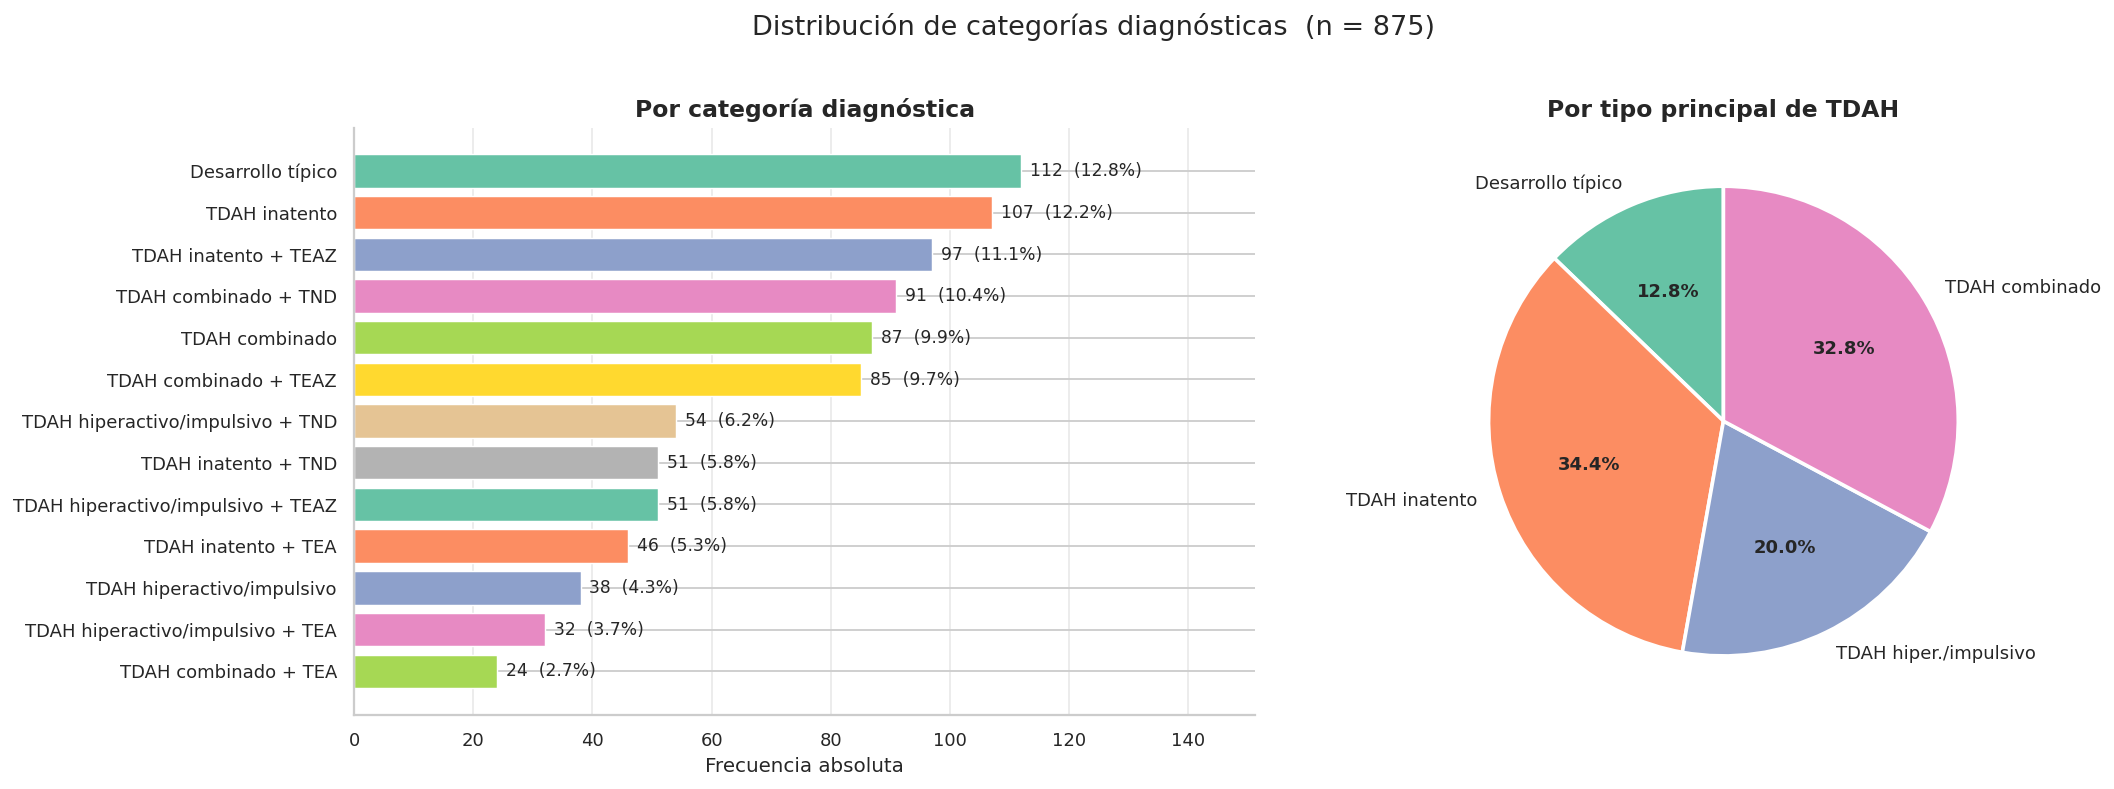

Más frecuente : Desarrollo típico — 112 casos (12.8%)
Menos frecuente: TDAH combinado + TEA — 24 casos (2.7%)
Ratio max/min : 4.7×


In [4]:
conteos = df['etiqueta'].value_counts()
pcts    = (conteos / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Distribución de categorías diagnósticas  (n = 875)", fontsize=15, y=1.01)

# ── Barras horizontales ──────────────────────────────────────
pal = sns.color_palette("Set2", len(conteos))
bars = axes[0].barh(range(len(conteos)), conteos.values[::-1],
                    color=pal[::-1], edgecolor='white', linewidth=0.8)
axes[0].set_yticks(range(len(conteos)))
axes[0].set_yticklabels(conteos.index[::-1], fontsize=10)
axes[0].set_xlabel("Frecuencia absoluta")
axes[0].set_title("Por categoría diagnóstica")
axes[0].set_xlim(0, conteos.max() * 1.35)
for bar, val, pct in zip(bars, conteos.values[::-1], pcts.values[::-1]):
    axes[0].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
                 f'{val}  ({pct}%)', va='center', fontsize=9.5)
axes[0].grid(axis='x', alpha=0.4)

# ── Pastel por tipo principal ────────────────────────────────
grupos = {
    'Desarrollo típico':     df['etiqueta'].str.contains('típico',      case=False).sum(),
    'TDAH inatento':         df['etiqueta'].str.contains('inatento',    case=False).sum(),
    'TDAH hiper./impulsivo': df['etiqueta'].str.contains('hiperactivo', case=False).sum(),
    'TDAH combinado':        df['etiqueta'].str.contains('combinado',   case=False).sum(),
}
wedges, texts, autotexts = axes[1].pie(
    grupos.values(), labels=grupos.keys(),
    autopct='%1.1f%%', colors=sns.color_palette("Set2", 4),
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title("Por tipo principal de TDAH")

plt.tight_layout()
plt.show()

print(f"Más frecuente : {conteos.index[0]} — {conteos.iloc[0]} casos ({pcts.iloc[0]}%)")
print(f"Menos frecuente: {conteos.index[-1]} — {conteos.iloc[-1]} casos ({pcts.iloc[-1]}%)")
print(f"Ratio max/min : {conteos.iloc[0] / conteos.iloc[-1]:.1f}×")


📋 **Interpretación — Distribución diagnóstica**

**Balance entre clases:** el ratio máximo/mínimo indica cuántas veces más casos tiene la categoría más frecuente respecto a la menos frecuente. Un ratio menor de 5× se considera un **desbalance moderado**, manejable para análisis descriptivo. Si el ratio fuera mayor de 10×, sería necesario considerar técnicas de balanceo en análisis supervisados posteriores.

**Desarrollo típico como control:** el grupo "Desarrollo típico" actúa como referencia clínica. Su presencia en la muestra es clave para el análisis bivariado: permite comparar los subtipos TDAH contra un grupo sin la condición, no solo entre subtipos.

**Subtipos con comorbilidades:** más de la mitad de los casos corresponden a subtipos que combinan TDAH con otra condición (TEA, TND, TEAZ). Esto refleja la alta comorbilidad del TDAH en la práctica clínica y señala que el análisis por subtipo puro vs. con comorbilidad será informativo en el bivariado.

**El pastel de tipos principales** agrupa las 13 categorías en 4, lo que facilita comunicar la composición de la muestra. El subtipo predominante en cada proyecto clínico puede variar según el centro de derivación.

---
## Bloque 2 — Variables demográficas

Incluye `edad` (6–12 años), `sexo`, `lateralidad` y `escolaridad` (grado escolar, 1–7).

> **Nota sobre escolaridad:** esta variable no cuenta con equivalencias en el diccionario de datos del proyecto. Se interpreta como grado escolar (1° a 7°), pero su codificación exacta debe confirmarse con la fuente original.

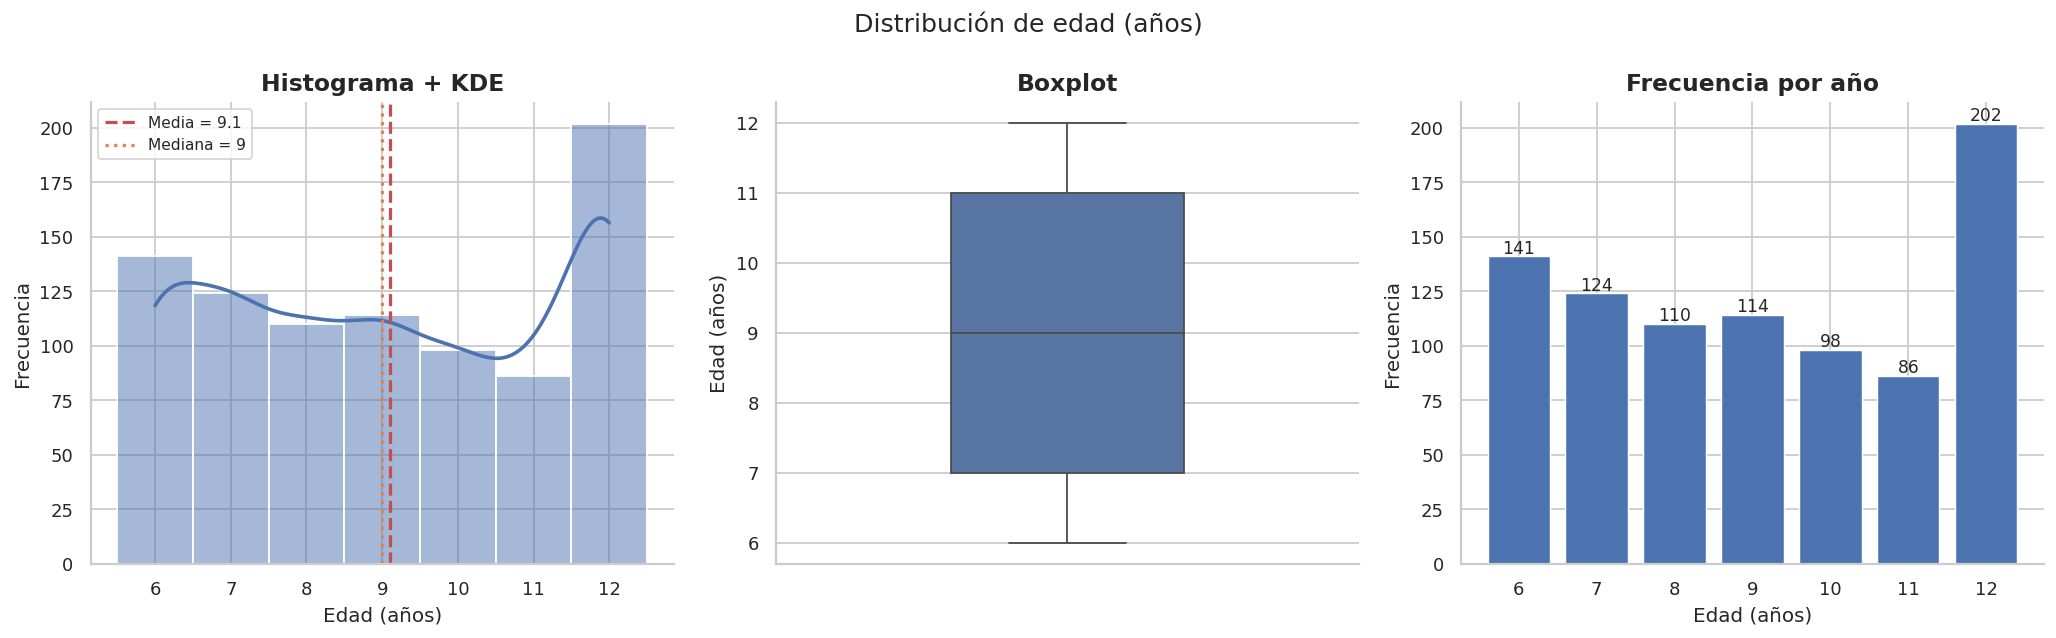

Media: 9.11  |  Mediana: 9  |  DS: 2.17
Asimetría: -0.002  |  Curtosis: -1.402


In [5]:
edad_counts = df['edad'].value_counts().sort_index()
sk_edad = stats.skew(df['edad'])
ku_edad = stats.kurtosis(df['edad'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de edad (años)", fontsize=14)

sns.histplot(df['edad'], ax=axes[0], kde=True, color=C_BLUE,
             discrete=True, edgecolor='white', line_kws={'linewidth': 2})
axes[0].axvline(df['edad'].mean(), color=C_RED, linestyle='--', linewidth=1.8,
                label=f'Media = {df["edad"].mean():.1f}')
axes[0].axvline(df['edad'].median(), color=C_ORG, linestyle=':', linewidth=1.8,
                label=f'Mediana = {df["edad"].median():.0f}')
axes[0].set_xlabel("Edad (años)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma + KDE"); axes[0].set_xticks(range(6, 13))
axes[0].legend(fontsize=8.5)

sns.boxplot(y=df['edad'], ax=axes[1], color=C_BLUE, width=0.4,
            flierprops={'marker': 'o', 'markerfacecolor': C_ORG, 'markersize': 5})
axes[1].set_ylabel("Edad (años)"); axes[1].set_title("Boxplot")
axes[1].set_yticks(range(6, 13))

bars_e = axes[2].bar(edad_counts.index, edad_counts.values, color=C_BLUE,
                     edgecolor='white', linewidth=0.8)
for bar in bars_e:
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 str(int(bar.get_height())), ha='center', fontsize=9.5)
axes[2].set_xlabel("Edad (años)"); axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Frecuencia por año"); axes[2].set_xticks(range(6, 13))

plt.tight_layout()
plt.show()

print(f"Media: {df['edad'].mean():.2f}  |  Mediana: {df['edad'].median():.0f}  |  DS: {df['edad'].std():.2f}")
print(f"Asimetría: {sk_edad:.3f}  |  Curtosis: {ku_edad:.3f}")


📋 **Interpretación — Edad**

**Cómo leer el histograma + KDE:** las barras muestran la frecuencia absoluta por año de edad. La curva KDE (Kernel Density Estimation) es una versión suavizada de esa distribución — permite ver la forma general sin depender del ancho de las barras.

**La línea roja (media) y la naranja (mediana):** si ambas son muy similares, la distribución es simétrica. Si difieren, la distribución tiene una cola en algún sentido. Cuando la mediana < media, hay una cola hacia la derecha (valores altos poco frecuentes).

**El pico en 12 años** es el elemento más llamativo. Puede tener dos explicaciones no excluyentes: (1) sesgo de derivación — los niños de mayor edad tienden a acumularse porque el diagnóstico se confirma más tardíamente cuando las demandas académicas se vuelven exigentes; o (2) la cohorte de 12 años representa el límite superior del criterio de inclusión, por lo que agrupa a todos los derivados a esa edad máxima.

**Asimetría:** un valor positivo indica cola hacia la derecha (pocos niños muy pequeños); negativo hacia la izquierda. Valores entre –0.5 y 0.5 se consideran distribuciones aproximadamente simétricas.

→ **Implicación para el bivariado:** si la edad difiere entre subtipos diagnósticos, podría indicar que ciertos diagnósticos se realizan más temprano o más tarde en el desarrollo.

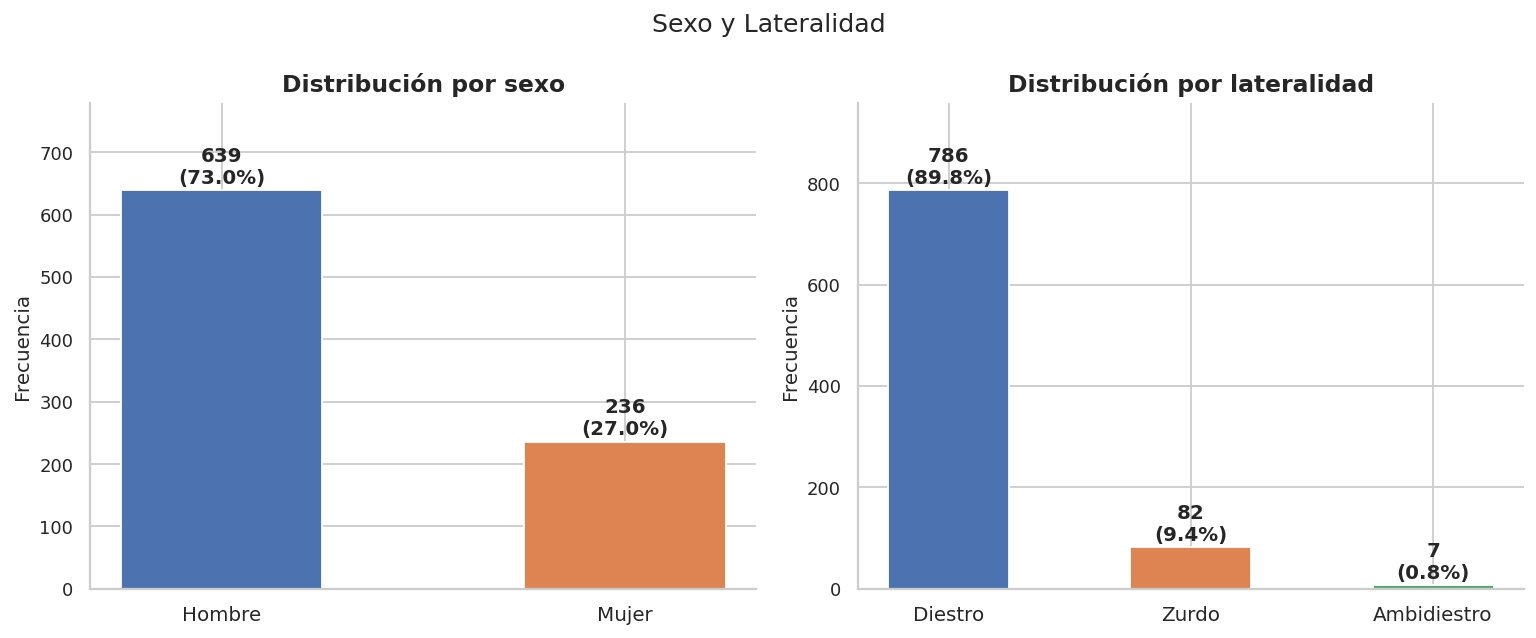

Ratio Hombre/Mujer: 2.71×


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sexo y Lateralidad", fontsize=14)

for ax, col, titulo, cols in zip(
    axes,
    ['sexo', 'lateralidad'],
    ['Distribución por sexo', 'Distribución por lateralidad'],
    [[C_BLUE, C_ORG], [C_BLUE, C_ORG, C_GRN]]
):
    counts = df[col].value_counts()
    bars   = ax.bar(counts.index, counts.values, color=cols[:len(counts)],
                    edgecolor='white', width=0.5)
    for bar in bars:
        pct = bar.get_height() / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f'{int(bar.get_height())}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(titulo); ax.set_ylabel("Frecuencia")
    ax.set_ylim(0, counts.max() * 1.22)
    ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

sexo = df['sexo'].value_counts()
print(f"Ratio Hombre/Mujer: {sexo['Hombre']/sexo['Mujer']:.2f}×")


📋 **Interpretación — Sexo y Lateralidad**

**Sexo — predominio masculino (≈ 73%):** esta proporción es consistente con la epidemiología del TDAH. La prevalencia en niños es 2–3 veces mayor que en niñas en edad escolar, en parte porque los niños presentan síntomas más **externalizados** (hiperactividad, impulsividad) que son más visibles y generan más derivaciones. Las niñas tienden a presentar el subtipo inatento, más silencioso y subdiagnosticado. Este desbalance no es un defecto del dataset — refleja la realidad clínica.

**Lateralidad — predominio diestro (≈ 90%):** coherente con la prevalencia general de la lateralidad derecha en la población (85–90%). Los zurdos y ambidiestros son una minoría pequeña, lo que limitará el poder estadístico en comparaciones que involucren lateralidad. No existe evidencia clínica sólida de que el TDAH esté asociado a un perfil de lateralidad específico.

→ **Implicación para el bivariado:** el desbalance de sexo debe tenerse presente al interpretar cualquier análisis por grupo diagnóstico. Si la proporción hombre/mujer varía entre subtipos, podría confundir otras comparaciones.

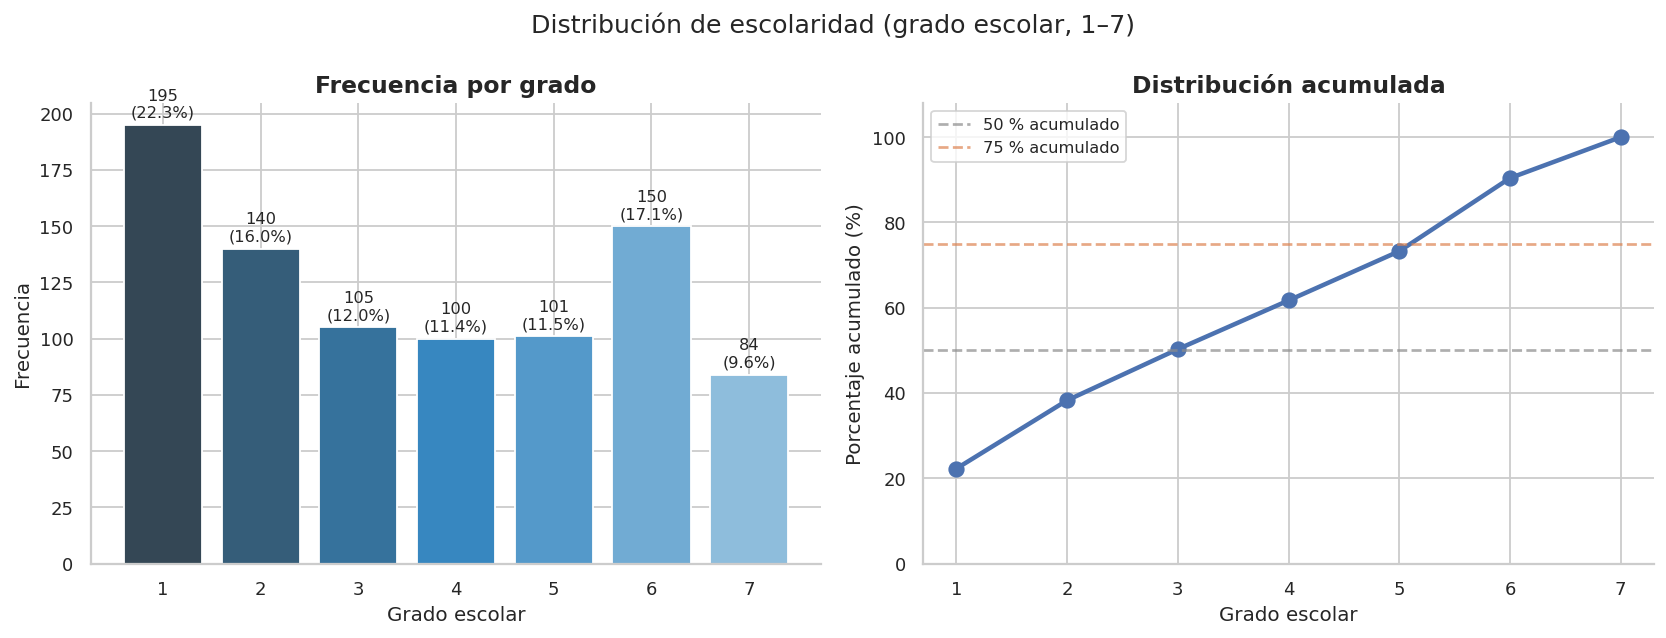

Grado más frecuente: 1° (195 casos, 22.3%)
Mediana: grado 3


In [7]:
esc_counts = df['escolaridad'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribución de escolaridad (grado escolar, 1–7)", fontsize=14)

pal_esc = sns.color_palette("Blues_d", len(esc_counts))[::-1]
bars_es = axes[0].bar(esc_counts.index, esc_counts.values, color=pal_esc, edgecolor='white')
for bar in bars_es:
    pct = bar.get_height() / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'{int(bar.get_height())}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel("Grado escolar"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Frecuencia por grado"); axes[0].set_xticks(range(1, 8))

acum = esc_counts.cumsum() / len(df) * 100
axes[1].plot(esc_counts.index, acum, marker='o', color=C_BLUE, linewidth=2.5, markersize=8)
axes[1].axhline(50, color=C_GRAY, linestyle='--', alpha=0.7, label='50 % acumulado')
axes[1].axhline(75, color=C_ORG,  linestyle='--', alpha=0.7, label='75 % acumulado')
axes[1].set_xlabel("Grado escolar"); axes[1].set_ylabel("Porcentaje acumulado (%)")
axes[1].set_title("Distribución acumulada"); axes[1].set_xticks(range(1, 8))
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 108)

plt.tight_layout()
plt.show()

print(f"Grado más frecuente: {esc_counts.idxmax()}° ({esc_counts.max()} casos, {esc_counts.max()/len(df)*100:.1f}%)")
print(f"Mediana: grado {df['escolaridad'].median():.0f}")


📋 **Interpretación — Escolaridad**

**Cómo leer la distribución acumulada:** la curva muestra qué porcentaje de la muestra corresponde a ese grado o uno inferior. Las líneas de referencia indican el grado en el que se alcanza el 50% y el 75% de la muestra. Si la curva sube abruptamente en un grado, ese grado concentra muchos casos.

**Relación con la edad:** escolaridad y edad están correlacionadas por construcción — a mayor edad corresponde mayor grado escolar. Si en el bivariado ambas variables muestran el mismo patrón respecto al diagnóstico, es redundante incluir las dos; en ese caso, conviene quedarse con la que tenga mayor relevancia clínica.

**Distribución hacia grados bajos:** que los grados 1–3 concentren una proporción importante de la muestra puede reflejar que la evaluación se realiza principalmente en los primeros años escolares, cuando las dificultades se hacen más evidentes al inicio de las demandas académicas formales.

---
## Bloque 3 — Antecedentes clínicos

Tres variables categóricas recogen el contexto clínico previo de cada paciente:

- **`antecedentes_familiares`:** historia familiar de TDAH u otros trastornos (refuerza la base genética del diagnóstico)
- **`antecedentes_obstetricos`:** complicaciones durante el embarazo o el parto (factores de riesgo perinatales)
- **`retrasos_desarrollo`:** áreas con retraso reportado en etapas tempranas del desarrollo (señal de impacto temprano en el neurodesarrollo)

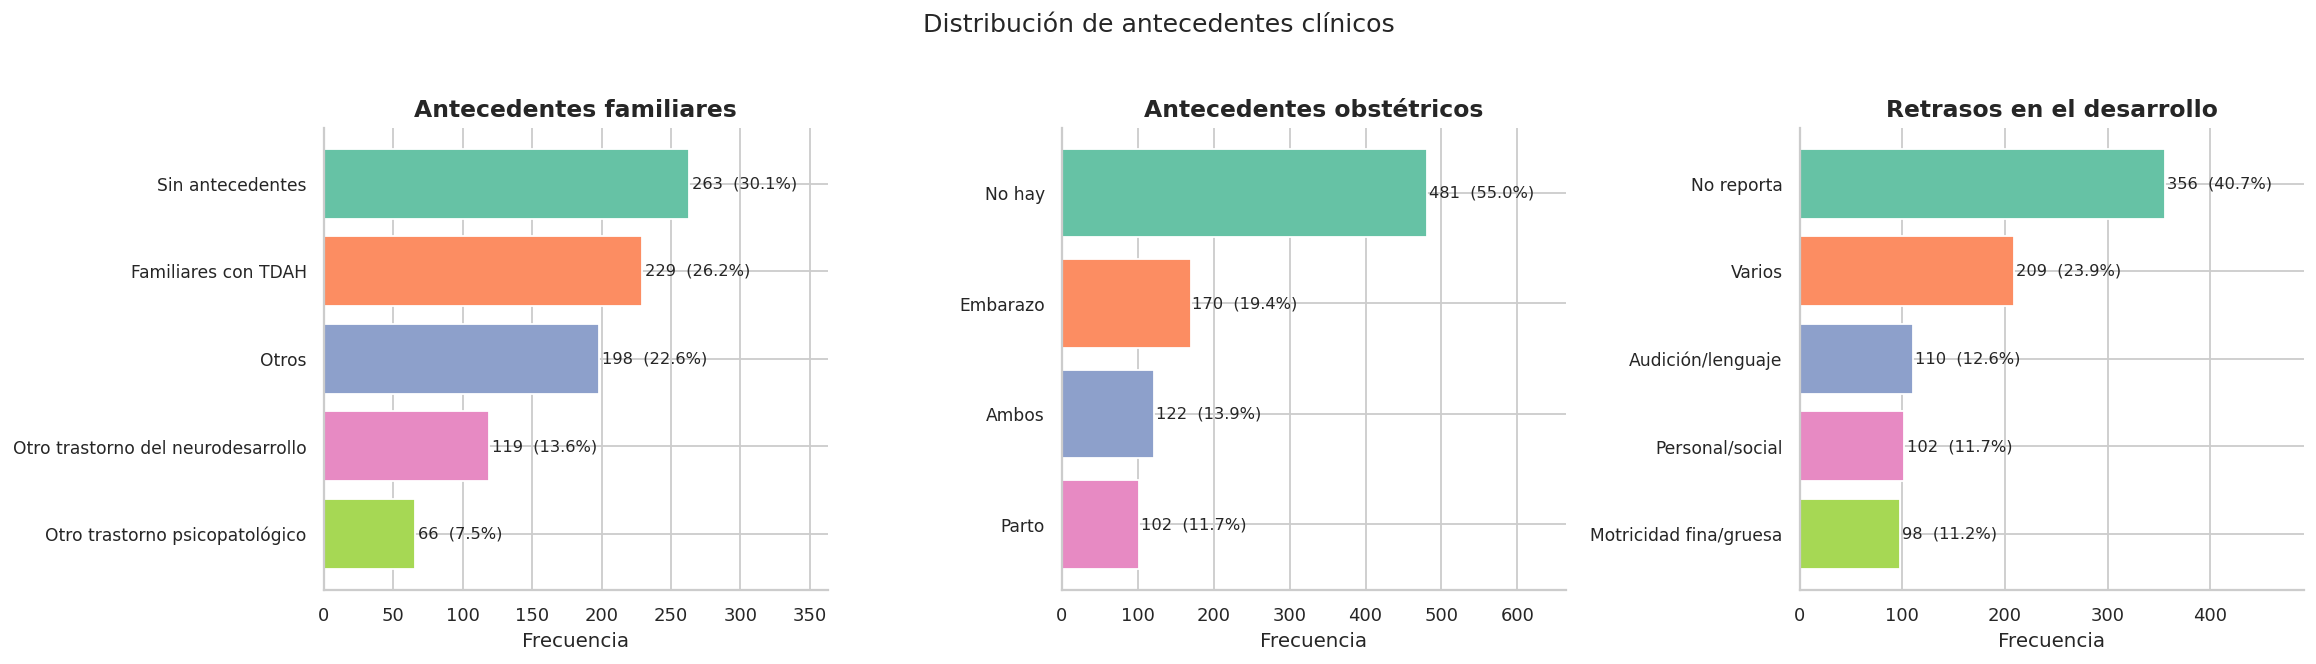

In [8]:
variables_ant = {
    'antecedentes_familiares':  'Antecedentes familiares',
    'antecedentes_obstetricos': 'Antecedentes obstétricos',
    'retrasos_desarrollo':      'Retrasos en el desarrollo',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución de antecedentes clínicos", fontsize=14, y=1.02)

for ax, (col, titulo) in zip(axes, variables_ant.items()):
    counts = df[col].value_counts()
    pcts_c = counts / len(df) * 100
    pal_c  = sns.color_palette("Set2", len(counts))
    bars_c = ax.barh(range(len(counts)), counts.values[::-1],
                     color=pal_c[::-1], edgecolor='white')
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index[::-1], fontsize=9.5)
    ax.set_xlabel("Frecuencia"); ax.set_title(titulo)
    ax.set_xlim(0, counts.max() * 1.38)
    for bar, val, pct in zip(bars_c, counts.values[::-1], pcts_c.values[::-1]):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f'{val}  ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()


📋 **Interpretación — Antecedentes clínicos**

**Antecedentes familiares:** la categoría más frecuente revela cuántos pacientes tienen historia familiar relevante. Una alta proporción de "Familiares con TDAH" refuerza la evidencia de heredabilidad de la condición (estimada entre 70–80% en estudios de gemelos). La presencia de "Sin antecedentes" como categoría frecuente no contradice esto — el TDAH también puede presentarse de novo por mutaciones o factores ambientales.

**Antecedentes obstétricos:** complicaciones durante el embarazo (exposición a tóxicos, infecciones, estrés prenatal) o el parto (hipoxia, prematuridad) son factores de riesgo bien documentados para el TDAH y otros trastornos del neurodesarrollo. La proporción de "No hay" indica qué tan frecuente es un historial perinatal sin incidentes en esta muestra.

**Retrasos en el desarrollo:** la presencia de retrasos en áreas como audición/lenguaje o motricidad antes del diagnóstico de TDAH sugiere que la afectación del neurodesarrollo es más amplia que el perfil atencional. Una alta proporción de "Varios" (múltiples áreas afectadas) indicaría perfiles más complejos.

→ **Implicación para el bivariado:** estas tres variables serán especialmente informativas al cruzarlas con la etiqueta diagnóstica para ver si ciertos antecedentes son más prevalentes en subtipos específicos (p.ej. los subtipos con comorbilidades).

→ **Cierre del bloque:** los antecedentes clínicos muestran una muestra heterogénea en su contexto previo — no hay un perfil único de antecedentes asociado al TDAH, lo que es consistente con su etiología multifactorial.

---
## Bloque 4 — Índices TDAH

Los tres índices cuantifican la presencia de síntomas en escala **0 a 1**:
- **0** = ningún síntoma presente en esa dimensión
- **1** = todos los síntomas presentes

El **`indice_tdah`** es el promedio de los otros dos. El **`indice_inatencion`** y el **`indice_impuls_hiperac`** representan las dos dimensiones clínicas del DSM-5.

**Umbral clínico — 0.5:** equivale a 6 de 9 síntomas, que es el criterio mínimo del DSM-5 para que una dimensión contribuya al diagnóstico. Un paciente con `indice_inatencion` ≥ 0.5 cumple el umbral de inatención clínicamente significativa.

> **Nota sobre la distribución:** se espera una distribución **multimodal o bimodal**, no normal. Esto es consecuencia del origen discreto de los índices: son proporciones calculadas sobre conteos enteros de síntomas, por lo que solo pueden tomar un número finito de valores (0/9, 1/9, 2/9 ... 9/9).

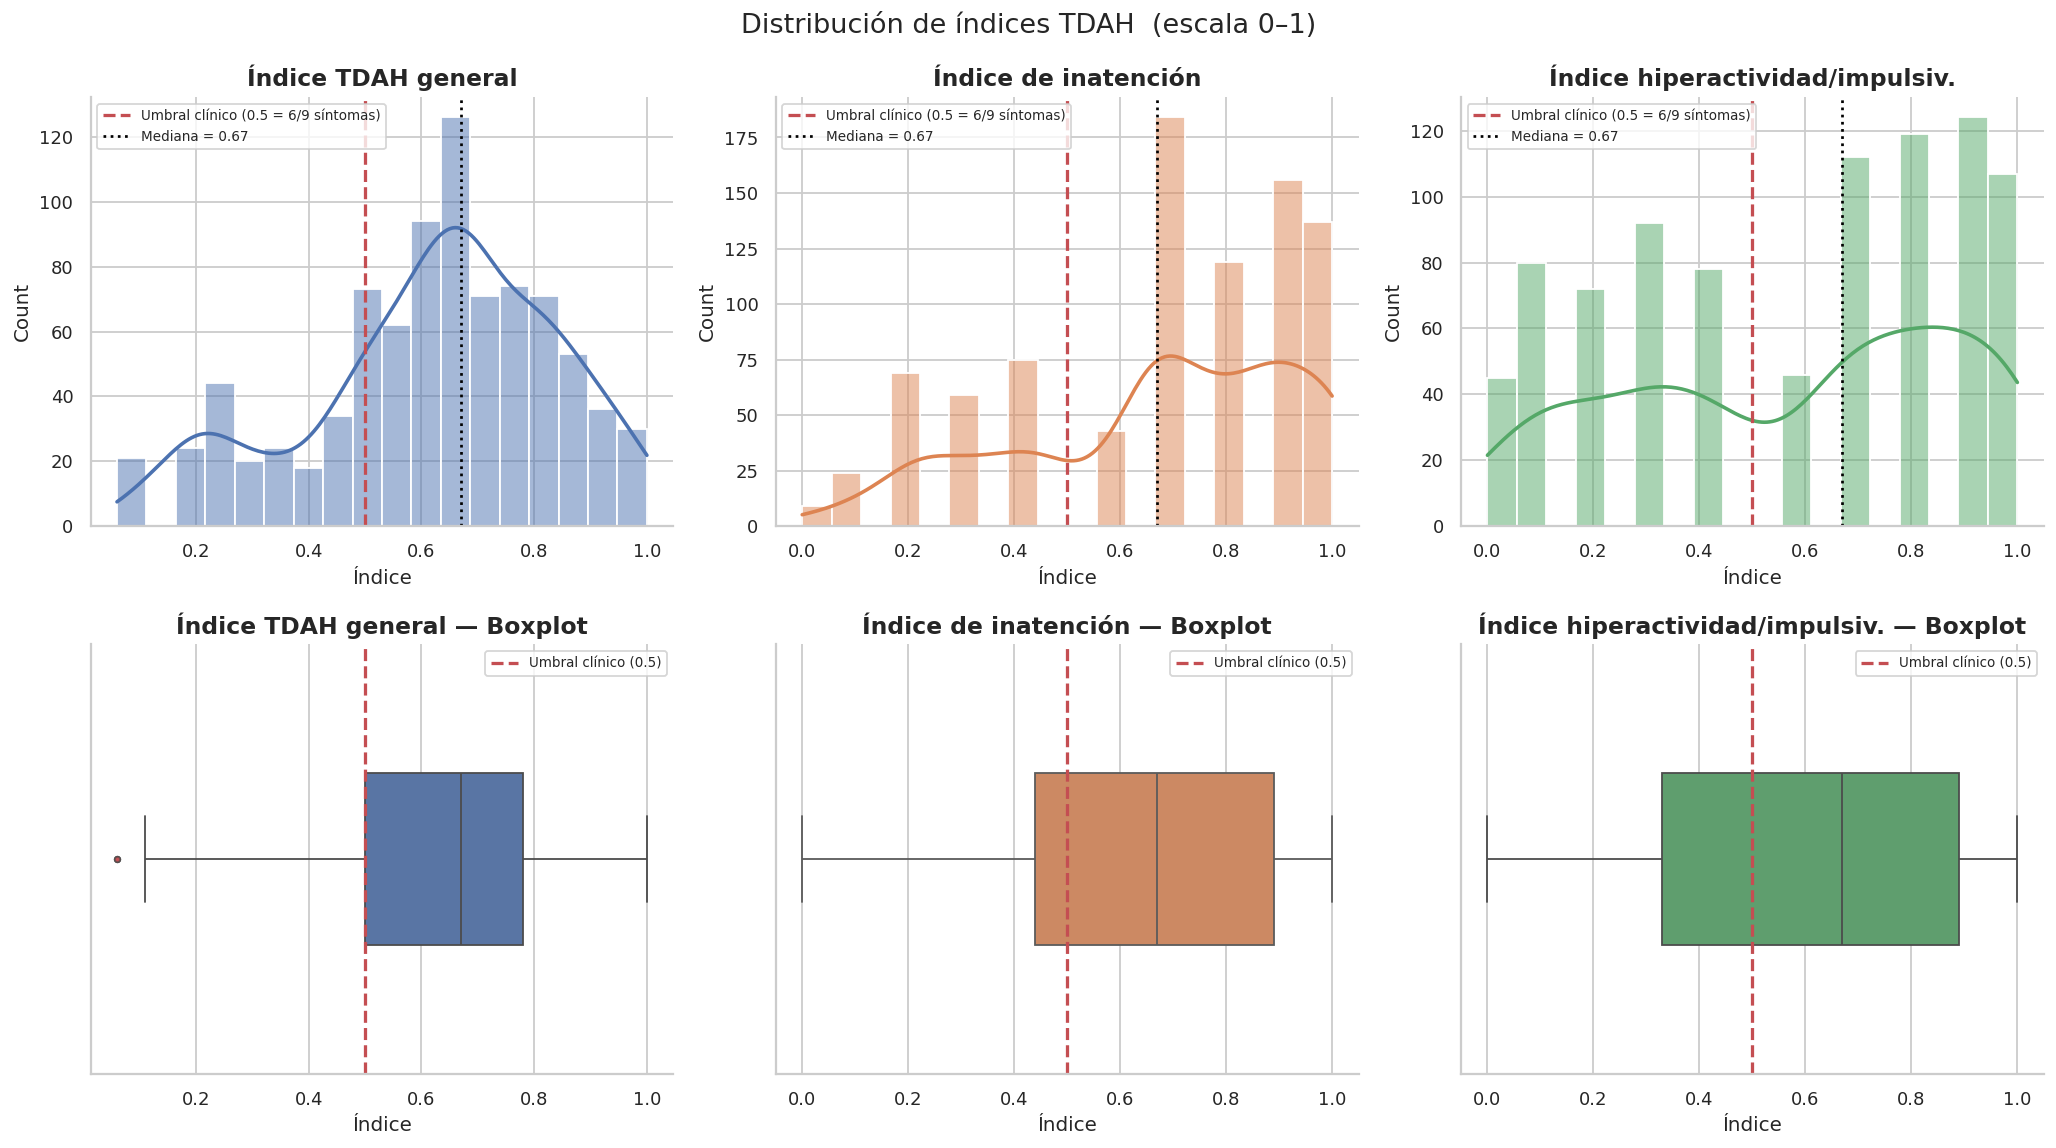

In [9]:
indices_meta = {
    'indice_tdah':           ('Índice TDAH general',             C_BLUE),
    'indice_inatencion':     ('Índice de inatención',            C_ORG),
    'indice_impuls_hiperac': ('Índice hiperactividad/impulsiv.', C_GRN),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribución de índices TDAH  (escala 0–1)", fontsize=15)

for j, (col, (titulo, color)) in enumerate(indices_meta.items()):
    ax_h = axes[0, j]
    ax_b = axes[1, j]

    sns.histplot(df[col], ax=ax_h, kde=True, color=color,
                 bins=18, edgecolor='white', line_kws={'linewidth': 2})
    ax_h.axvline(0.5, color=C_RED, linestyle='--', linewidth=1.8,
                 label='Umbral clínico (0.5 = 6/9 síntomas)')
    ax_h.axvline(df[col].median(), color='black', linestyle=':', linewidth=1.5,
                 label=f'Mediana = {df[col].median():.2f}')
    ax_h.set_title(titulo); ax_h.set_xlabel("Índice"); ax_h.legend(fontsize=7.5)

    sns.boxplot(x=df[col], ax=ax_b, color=color, width=0.4,
                flierprops={'marker': 'o', 'markerfacecolor': C_RED,
                            'markersize': 3, 'alpha': 0.5})
    ax_b.axvline(0.5, color=C_RED, linestyle='--', linewidth=1.8,
                 label='Umbral clínico (0.5)')
    ax_b.legend(fontsize=7.5)
    ax_b.set_xlabel("Índice"); ax_b.set_title(f"{titulo} — Boxplot")

plt.tight_layout()
plt.show()


📋 **Interpretación — Índices TDAH**

**Cómo leer el histograma con KDE:** las barras muestran cuántos pacientes tienen ese valor de índice. La curva KDE suaviza la distribución. En estos índices es normal ver **picos discretos** porque los valores posibles son limitados (fracciones de 9 síntomas: 0, 1/9≈0.11, 2/9≈0.22, etc.).

**La línea roja (umbral 0.5):** separa los casos por debajo del criterio diagnóstico de los que lo cumplen. Una masa importante de casos por encima de 0.5 en `indice_inatencion` es esperable dado que la muestra incluye mayoritariamente niños con TDAH.

**Cómo leer el boxplot:** la caja cubre el 50% central de los datos (Q1 a Q3). La línea interior es la mediana. Los puntos fuera de los bigotes son valores atípicos. Si el boxplot está muy desplazado hacia un extremo, la distribución es asimétrica.

**Qué esperar según el subtipo:**
- `indice_inatencion` debería tener muchos valores altos (la mayoría de la muestra tiene TDAH inatento o combinado).
- `indice_impuls_hiperac` debería tener distribución más bimodal: alta en hiperactivos/combinados, baja en inatento puro y desarrollo típico.

→ **Cierre del bloque:** la distribución multimodal y la concentración de casos cerca del umbral 0.5 confirman que los índices reflejan fielmente el criterio diagnóstico. La separación entre casos bajo y sobre el umbral es una señal de calidad de los datos.

In [10]:
print(f"{'Variable':<26} {'Media':>6} {'Med':>6} {'DS':>6} {'Skew':>7} {'Kurt':>7}  {'SW-p':>9}  {'≥0.5':>6}")
print("─" * 85)
for col, (titulo, _) in indices_meta.items():
    m   = df[col].mean();   med = df[col].median(); sd = df[col].std()
    sk  = stats.skew(df[col]); ku = stats.kurtosis(df[col])
    _, p_sw = stats.shapiro(df[col])
    pct_umbral = (df[col] >= 0.5).mean() * 100
    print(f"{col:<26} {m:>6.3f} {med:>6.3f} {sd:>6.3f} {sk:>7.3f} {ku:>7.3f}  {p_sw:>9.2e}  {pct_umbral:>5.1f}%")


Variable                    Media    Med     DS    Skew    Kurt       SW-p    ≥0.5
─────────────────────────────────────────────────────────────────────────────────────
indice_tdah                 0.621  0.670  0.222  -0.531  -0.324   2.81e-15   78.9%
indice_inatencion           0.670  0.670  0.264  -0.610  -0.625   8.71e-22   73.0%
indice_impuls_hiperac       0.572  0.670  0.313  -0.272  -1.220   6.51e-21   58.1%


📋 **Interpretación — Estadísticos de los índices TDAH**

**Asimetría (Skew):** valores positivos indican que la cola es hacia la derecha (pocos casos con índice muy alto); negativos hacia la izquierda (pocos casos muy bajos). En `indice_inatencion` se espera asimetría negativa — la mayoría de la muestra tiene valores altos. En `indice_impuls_hiperac` se espera mayor variabilidad.

**Curtosis:** mide el peso de las colas. Curtosis positiva (leptocúrtica) significa colas pesadas — más valores extremos de lo esperado en una distribución normal. En índices basados en conteos discretos, la curtosis es típicamente positiva.

**Shapiro-Wilk (SW-p):** p < 0.05 rechaza la hipótesis de normalidad. Se espera que los tres índices tengan p muy bajo — confirmando que no siguen distribución normal y justificando el uso de pruebas no paramétricas en el análisis bivariado.

**Columna "≥ 0.5":** porcentaje de casos que superan el umbral clínico en cada dimensión. Este valor informa directamente sobre cuántos pacientes de la muestra presentan esa dimensión de forma clínicamente significativa.

---
## Bloque 5 — Coeficiente Intelectual Total (CIT)

El CIT proviene de una evaluación estandarizada tipo Wechsler. En la **población general** se distribuye con media = 100 y desviación estándar = 15.

| Rango CIT | Clasificación |
|-----------|---------------|
| ≥ 130 | Muy superior |
| 120–129 | Superior |
| 110–119 | Promedio alto |
| **90–109** | **Promedio** |
| 80–89 | Bajo promedio |
| 70–79 | Límite |
| < 70 | Discapacidad intelectual |

La línea de referencia en los gráficos se ubica en **CIT = 90** (límite inferior del rango promedio) porque por debajo de este valor las dificultades cognitivas comienzan a ser clínicamente relevantes y pueden requerir intervención adicional al TDAH.

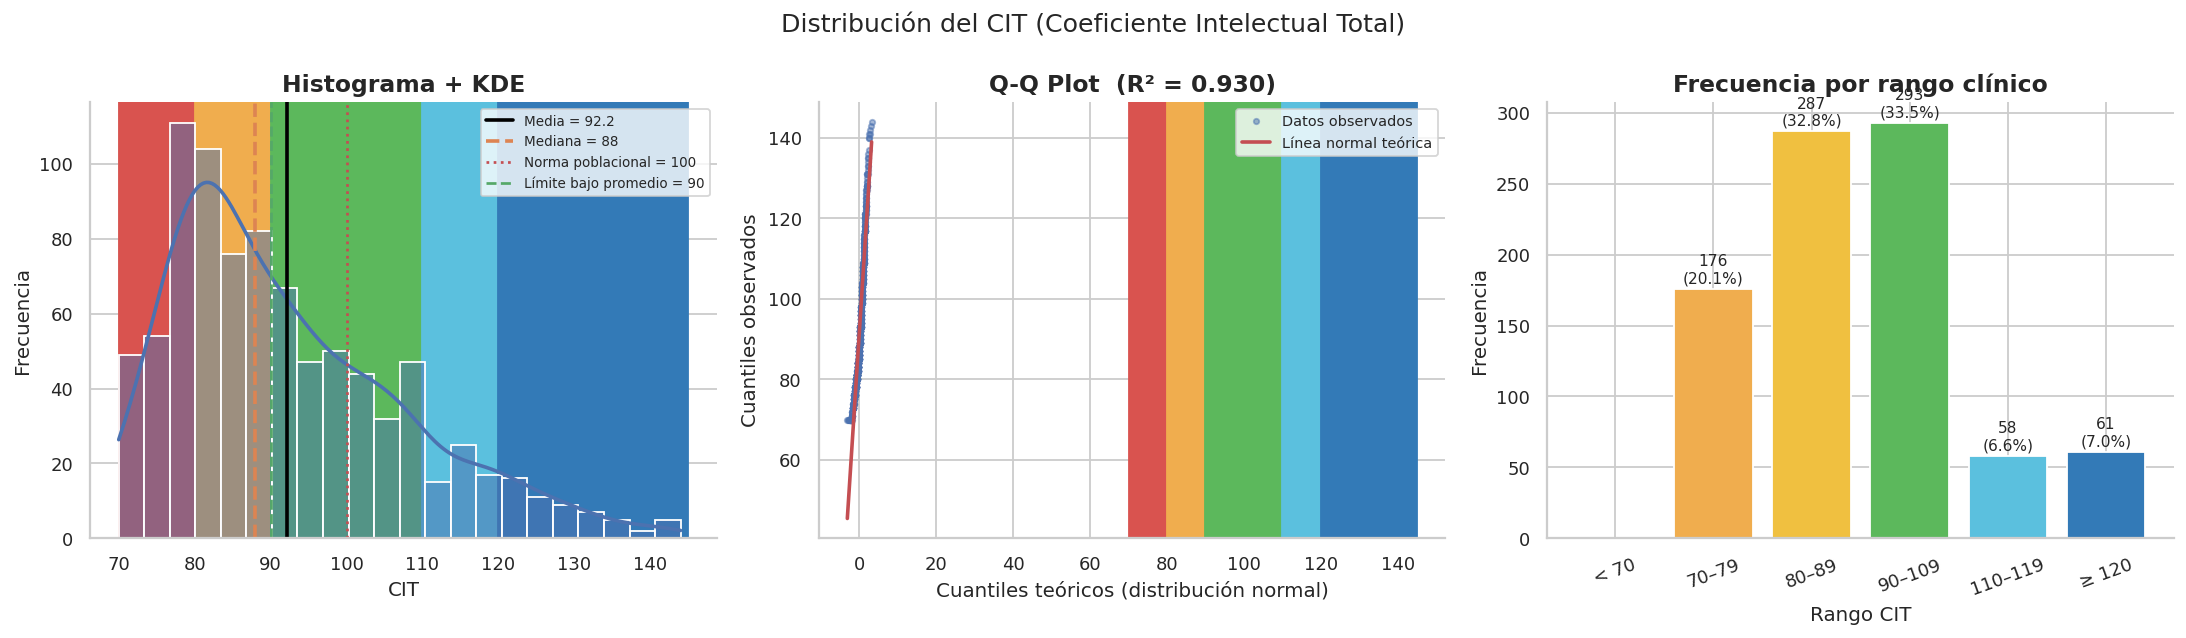

Media: 92.23  |  Mediana: 88  |  DS: 15.32
Rango: 70 – 144
Asimetría: 0.921  |  Curtosis: 0.335
Shapiro-Wilk      : p = 6.75e-20
Kolmogorov-Smirnov: p = 3.88e-10


In [11]:
rangos_cit_vis = [
    (70,  80,  '#d9534f22'), (80,  90,  '#f0ad4e22'),
    (90,  110, '#5cb85c22'), (110, 120, '#5bc0de22'), (120, 145, '#337ab722'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Distribución del CIT (Coeficiente Intelectual Total)", fontsize=14)

for ax in axes[:2]:
    for lo, hi, color in rangos_cit_vis:
        ax.axvspan(lo, hi, alpha=1, color=color)

sns.histplot(df['cit'], ax=axes[0], kde=True, color=C_BLUE,
             bins=22, edgecolor='white', line_kws={'linewidth': 2})
axes[0].axvline(df['cit'].mean(),   color='black', linestyle='-',  linewidth=2,
                label=f'Media = {df["cit"].mean():.1f}')
axes[0].axvline(df['cit'].median(), color=C_ORG,   linestyle='--', linewidth=2,
                label=f'Mediana = {df["cit"].median():.0f}')
axes[0].axvline(100, color=C_RED, linestyle=':', linewidth=1.5, label='Norma poblacional = 100')
axes[0].axvline(90,  color=C_GRN, linestyle='--', linewidth=1.5, label='Límite bajo promedio = 90')
axes[0].set_xlabel("CIT"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma + KDE"); axes[0].legend(fontsize=7.5)

(osm, osr), (slope, intercept, r) = stats.probplot(df['cit'], dist='norm')
axes[1].plot(osm, osr, 'o', color=C_BLUE, markersize=3, alpha=0.5, label='Datos observados')
axes[1].plot(osm, slope * osm + intercept, color=C_RED, linewidth=2, label='Línea normal teórica')
axes[1].set_xlabel("Cuantiles teóricos (distribución normal)")
axes[1].set_ylabel("Cuantiles observados")
axes[1].set_title(f"Q-Q Plot  (R² = {r**2:.3f})")
axes[1].legend(fontsize=8)

etq_r = []
for v in df['cit']:
    if   v < 70:  etq_r.append('< 70')
    elif v < 80:  etq_r.append('70–79')
    elif v < 90:  etq_r.append('80–89')
    elif v < 110: etq_r.append('90–109')
    elif v < 120: etq_r.append('110–119')
    else:         etq_r.append('≥ 120')
orden_r = ['< 70', '70–79', '80–89', '90–109', '110–119', '≥ 120']
rc = pd.Series(etq_r).value_counts().reindex(orden_r, fill_value=0)
cols_r = ['#d9534f', '#f0ad4e', '#f0c040', '#5cb85c', '#5bc0de', '#337ab7']
bars_r = axes[2].bar(orden_r, rc.values, color=cols_r, edgecolor='white')
for bar in bars_r:
    pct = bar.get_height() / len(df) * 100
    if pct > 0:
        axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                     f'{int(bar.get_height())}\n({pct:.1f}%)',
                     ha='center', va='bottom', fontsize=8.5)
axes[2].set_xlabel("Rango CIT"); axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Frecuencia por rango clínico")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

sk_c = stats.skew(df['cit']); ku_c = stats.kurtosis(df['cit'])
_, p_sw = stats.shapiro(df['cit'])
_, p_ks = stats.kstest(stats.zscore(df['cit']), 'norm')
print(f"Media: {df['cit'].mean():.2f}  |  Mediana: {df['cit'].median():.0f}  |  DS: {df['cit'].std():.2f}")
print(f"Rango: {df['cit'].min()} – {df['cit'].max()}")
print(f"Asimetría: {sk_c:.3f}  |  Curtosis: {ku_c:.3f}")
print(f"Shapiro-Wilk      : p = {p_sw:.2e}")
print(f"Kolmogorov-Smirnov: p = {p_ks:.2e}")


📋 **Interpretación — CIT**

**Cómo leer el histograma con bandas de color:** cada banda de fondo corresponde a un rango de clasificación clínica del CIT. La banda verde (90–109) es el rango promedio. Observar qué proporción de la distribución cae en cada zona permite ubicar la muestra respecto a la norma poblacional de forma inmediata.

**La línea roja punteada (CIT = 100)** es la media poblacional. Si la media o mediana de la muestra está por debajo, indica que en promedio la capacidad cognitiva de este grupo es inferior a la norma — esperable en una muestra clínica de TDAH.

**Cómo leer el Q-Q Plot:** compara los cuantiles de los datos reales contra los cuantiles de una distribución normal teórica. Si los puntos siguen la línea roja, los datos son normales. Las desviaciones al inicio y al final de la línea (colas) indican que la distribución tiene colas más pesadas o más ligeras que la normal. Un R² cercano a 1 indica buen ajuste a la normalidad — pero los tests formales (Shapiro-Wilk, KS) son más rigurosos.

**Media vs norma poblacional:** si la media muestral está notablemente por debajo de 100, no implica que el TDAH cause baja inteligencia — puede reflejar que el proceso de evaluación tiende a derivar a niños con mayores dificultades cognitivas. También puede haber un sesgo de selección: niños con CIT más bajo tienen más probabilidad de llegar a evaluación especializada.

→ **Cierre del bloque:** la distribución del CIT en esta muestra revela el perfil cognitivo global. Las diferencias entre grupos diagnósticos en CIT (exploradas en el bivariado) son más informativas que la distribución general.

---
## Bloque 6 — Escalas BASC-3

Las cinco escalas del BASC-3 están en **puntajes T**: una escala estandarizada en la población general con **media = 50** y **desviación estándar = 10**.

Esto significa que:
- Un niño con T = 50 está exactamente en la media de la población normativa de su edad.
- Un niño con T = 60 está **una desviación estándar** por encima — el 84% de la población tiene puntajes menores.
- Un niño con T = 70 está **dos desviaciones estándar** por encima — el 97.7% de la población tiene puntajes menores.

| Puntaje T | Zona clínica |
|-----------|-------------|
| < 60 | Normal / Sin indicación clínica |
| 60–69 | **Zona de riesgo** (*At-Risk*) — requiere monitoreo |
| ≥ 70 | **Clínicamente significativo** — requiere atención activa |

**Las cinco escalas miden:**
- `agresividad_basc3` — comportamientos agresivos hacia personas u objetos
- `hiperactividad_basc3` — actividad excesiva e impulsividad conductual
- `problemas_conducta_basc3` — comportamientos negativistas o disruptivos
- `problemas_atencion_basc3` — dificultades para mantener la concentración
- `atipicidad_basc3` — comportamientos inusuales o fuera de lo esperado para la edad

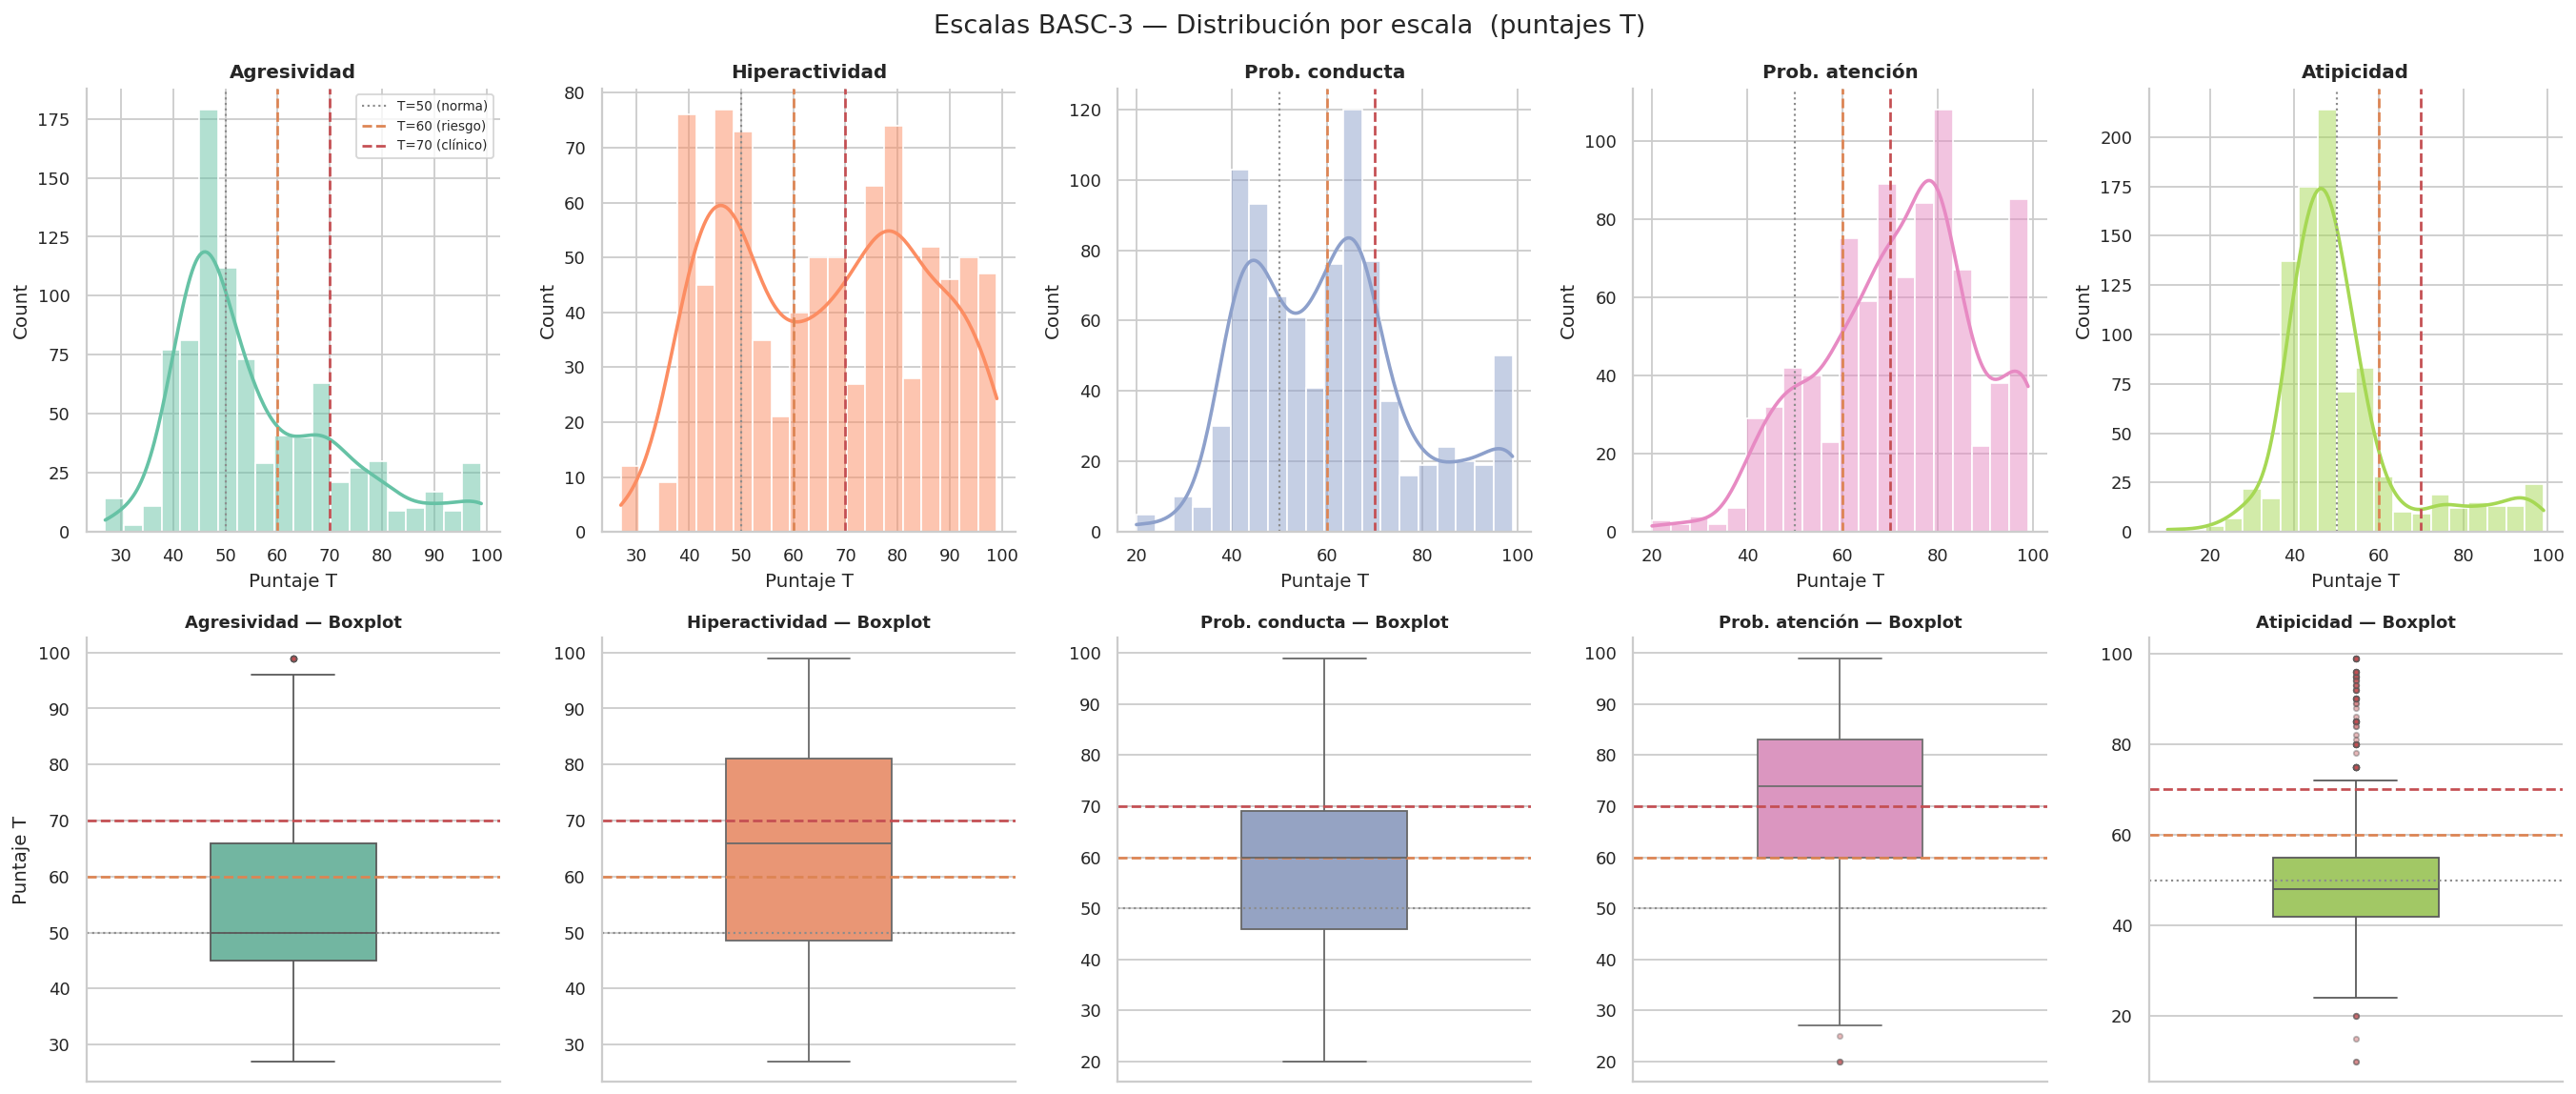

In [12]:
labels_basc = {
    'agresividad_basc3':        'Agresividad',
    'hiperactividad_basc3':     'Hiperactividad',
    'problemas_conducta_basc3': 'Prob. conducta',
    'problemas_atencion_basc3': 'Prob. atención',
    'atipicidad_basc3':         'Atipicidad',
}
pal_basc = sns.color_palette("Set2", 5)

fig, axes = plt.subplots(2, 5, figsize=(21, 9))
fig.suptitle("Escalas BASC-3 — Distribución por escala  (puntajes T)", fontsize=15)

for i, (col, label) in enumerate(labels_basc.items()):
    ax_h = axes[0, i]
    ax_b = axes[1, i]

    sns.histplot(df[col], ax=ax_h, kde=True, color=pal_basc[i],
                 bins=20, edgecolor='white', line_kws={'linewidth': 2})
    ax_h.axvline(50, color=C_GRAY, linestyle=':',  linewidth=1.2, label='T=50 (norma)')
    ax_h.axvline(60, color=C_ORG,  linestyle='--', linewidth=1.5, label='T=60 (riesgo)')
    ax_h.axvline(70, color=C_RED,  linestyle='--', linewidth=1.5, label='T=70 (clínico)')
    ax_h.set_title(label, fontsize=11); ax_h.set_xlabel("Puntaje T")
    if i == 0:
        ax_h.legend(fontsize=7.5)

    sns.boxplot(y=df[col], ax=ax_b, color=pal_basc[i], width=0.4,
                flierprops={'marker': 'o', 'markerfacecolor': C_RED,
                            'markersize': 3, 'alpha': 0.4})
    ax_b.axhline(50, color=C_GRAY, linestyle=':',  linewidth=1.2, label='T=50 (norma)')
    ax_b.axhline(60, color=C_ORG,  linestyle='--', linewidth=1.5, label='T=60 (riesgo)')
    ax_b.axhline(70, color=C_RED,  linestyle='--', linewidth=1.5, label='T=70 (clínico)')
    ax_b.set_ylabel("Puntaje T" if i == 0 else "")
    ax_b.set_title(f"{label} — Boxplot", fontsize=10)

plt.tight_layout()
plt.show()


📋 **Interpretación — Distribuciones BASC-3**

**Cómo leer las tres líneas de referencia:**
- **T = 50** (gris punteada): media de la población normativa. Cualquier grupo de niños típicos debería concentrarse aquí.
- **T = 60** (naranja): zona de riesgo. Un niño con este puntaje ya supera al 84% de la población normativa en esa conducta. Es una señal de alerta que recomienda seguimiento.
- **T = 70** (roja): zona clínicamente significativa. Supera al 97.7% de la población normativa. A este nivel se justifica una intervención activa.

**Qué observar en los histogramas:** si la distribución se concentra por encima de T = 60, significa que la mayoría de la muestra ya está en zona de riesgo o clínica en esa escala — lo cual es esperable en una muestra de pacientes evaluados para TDAH.

**Qué observar en los boxplots:** la posición de la caja respecto a las líneas de referencia indica dónde se concentra el 50% central de la muestra. Si la mediana (línea central de la caja) está sobre T = 60, más de la mitad de los pacientes están en zona de riesgo o peor en esa dimensión.

**Diferencias entre escalas esperadas:**
- **Hiperactividad y Prob. atención** deberían estar más elevadas (son el núcleo del TDAH).
- **Agresividad y Prob. conducta** pueden ser más variables — están más ligadas a comorbilidades conductuales que al TDAH per se.
- **Atipicidad** tiende a ser la más dispersa — recordar que tuvo el mayor número de outliers IQR en el análisis previo.

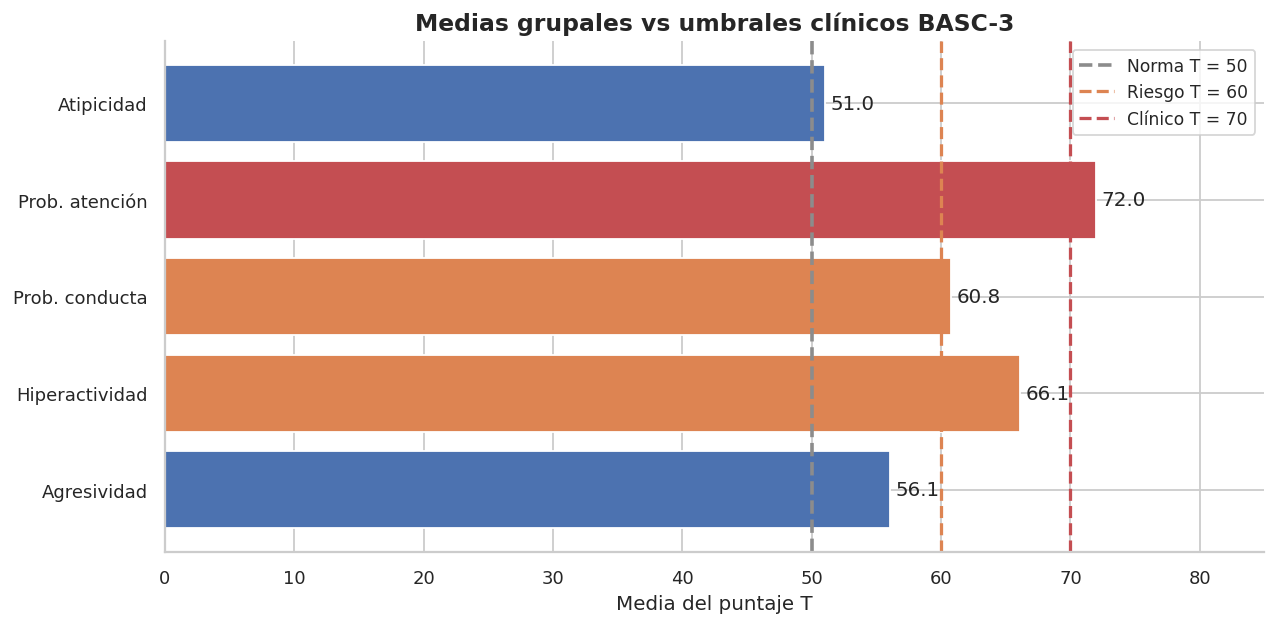

Escala                      Media    Med     DS    Skew    Kurt    ≥T60    ≥T70
────────────────────────────────────────────────────────────────────────────────
Agresividad                  56.1   50.0  15.86   1.009   0.350   33.8%   20.6%
Hiperactividad               66.1   66.0  19.16   0.026  -1.229   60.2%   48.6%
Prob. conducta               60.8   60.0  17.27   0.508  -0.307   52.3%   24.9%
Prob. atención               72.0   74.0  16.47  -0.324  -0.361   79.1%   59.9%
Atipicidad                   51.0   48.0  14.98   1.462   2.297   15.9%   11.9%


In [13]:
# ── Medias grupales vs umbrales clínicos ─────────────────────
medias_basc = {labels_basc[c]: df[c].mean() for c in labels_basc}

fig, ax = plt.subplots(figsize=(10, 5))
colores_b = [C_RED if v >= 70 else C_ORG if v >= 60 else C_BLUE for v in medias_basc.values()]
bars_b = ax.barh(list(medias_basc.keys()), list(medias_basc.values()),
                 color=colores_b, edgecolor='white')
ax.axvline(50, color=C_GRAY, linestyle='--', linewidth=2,   label='Norma T = 50')
ax.axvline(60, color=C_ORG,  linestyle='--', linewidth=1.8, label='Riesgo T = 60')
ax.axvline(70, color=C_RED,  linestyle='--', linewidth=1.8, label='Clínico T = 70')
for bar, val in zip(bars_b, medias_basc.values()):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=11)
ax.set_xlabel("Media del puntaje T")
ax.set_title("Medias grupales vs umbrales clínicos BASC-3")
ax.legend(fontsize=9.5)
ax.set_xlim(0, max(medias_basc.values()) * 1.18)
plt.tight_layout()
plt.show()

print(f"{'Escala':<26} {'Media':>6} {'Med':>6} {'DS':>6} {'Skew':>7} {'Kurt':>7}  {'≥T60':>6}  {'≥T70':>6}")
print("─" * 80)
for col, label in labels_basc.items():
    m   = df[col].mean(); med = df[col].median(); sd = df[col].std()
    sk  = stats.skew(df[col]); ku = stats.kurtosis(df[col])
    p60 = (df[col] >= 60).mean() * 100
    p70 = (df[col] >= 70).mean() * 100
    print(f"{label:<26} {m:>6.1f} {med:>6.1f} {sd:>6.2f} {sk:>7.3f} {ku:>7.3f}  {p60:>5.1f}%  {p70:>5.1f}%")


📋 **Interpretación — Medias BASC-3 vs umbrales**

**Cómo leer las barras:** el color de cada barra indica en qué zona clínica se ubica la media de ese grupo:
- **Azul** → la media grupal está dentro del rango normal (T < 60)
- **Naranja** → la media grupal está en zona de riesgo (T 60–69) — más de la mitad de los pacientes, en promedio, están en zona de alerta
- **Rojo** → la media grupal está en zona clínicamente significativa (T ≥ 70)

**Columnas ≥T60 y ≥T70 en la tabla:** muestran qué porcentaje de los 875 pacientes supera cada umbral en cada escala. Son más informativos que la media porque la media puede esconder que una minoría tiene puntajes muy altos elevando el promedio.

**La escala más elevada** (la barra más larga) es la que más se aleja de la norma poblacional y la que más podría discriminar entre subtipos diagnósticos en el bivariado.

→ **Cierre del bloque:** las escalas BASC-3 confirman que la muestra presenta perfiles clínicamente elevados, especialmente en las dimensiones más directamente relacionadas con el TDAH. La variabilidad entre escalas sugiere que no todas miden el mismo constructo — algo que el análisis bivariado explorará en detalle.

---
## Bloque 7 — Fluidez fonológica

La tarea de fluidez fonológica mide cuántas palabras genera el niño comenzando con una letra específica en un tiempo limitado (generalmente 60 segundos). Es una medida sensible a:
- **Velocidad de acceso léxico** — qué tan rápido el niño puede recuperar palabras de su vocabulario
- **Memoria de trabajo** — mantener activa la regla (letra inicial) mientras genera respuestas
- **Función ejecutiva** — inhibir palabras que no empiezan con la letra correcta y organizar la búsqueda

**No hay un baremo universal fijo** en este dataset: los valores se interpretan de forma relativa entre grupos. Puntajes bajos pueden indicar dificultades en estas áreas, pero también pueden estar influidos por el nivel socioeconómico, la exposición al lenguaje y otros factores.

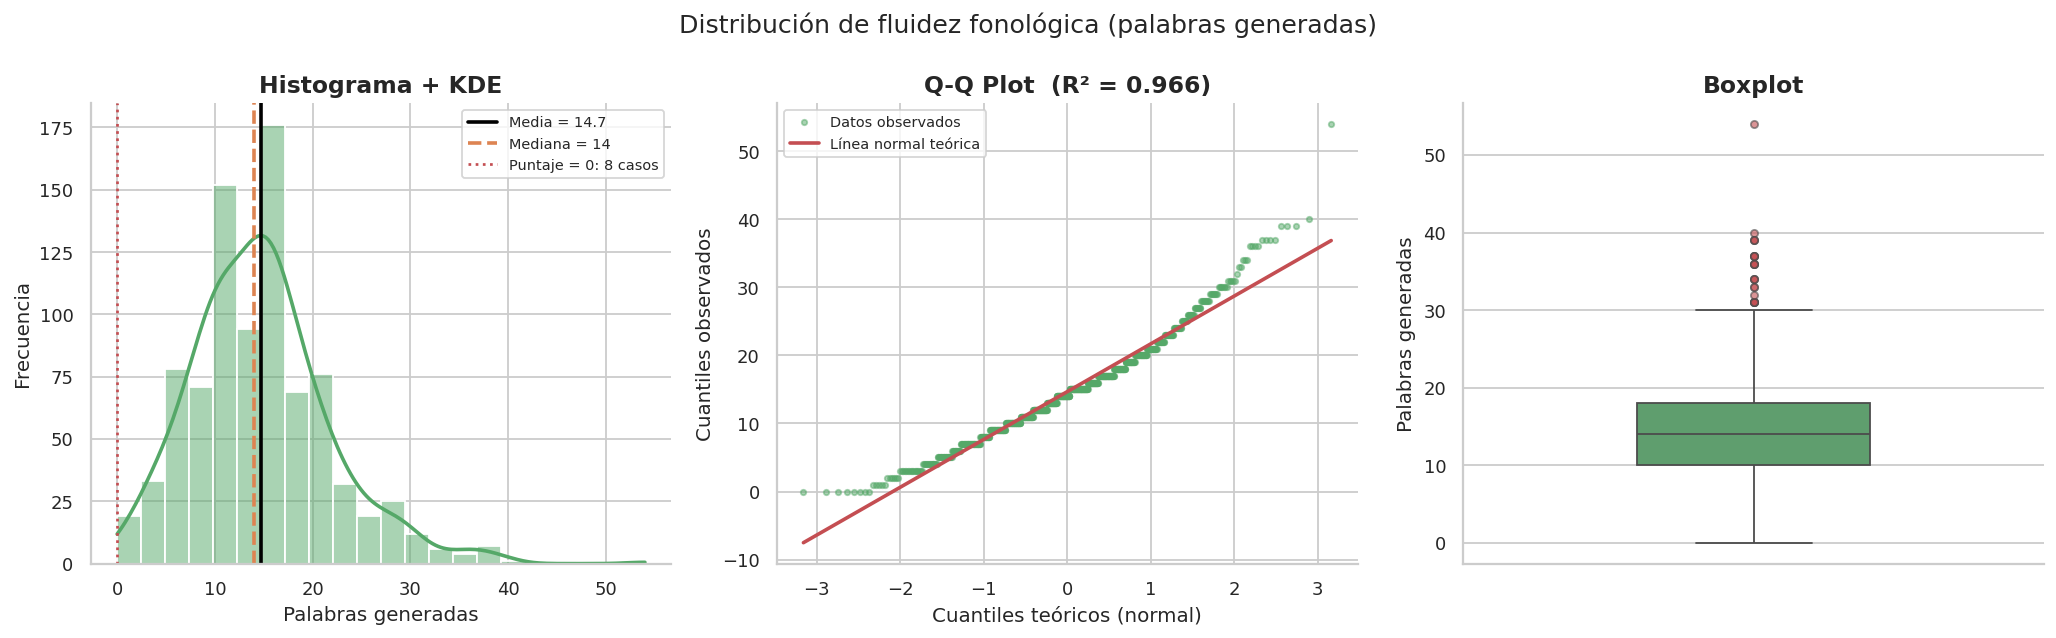

Media: 14.68  |  Mediana: 14  |  DS: 7.13
Rango: 0 – 54
Asimetría: 0.786  |  Curtosis: 1.567
Shapiro-Wilk: p = 2.37e-13
Casos con puntaje = 0: 8  (0.9%)


In [14]:
ceros_ff = (df['fluidez_fonologica'] == 0).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de fluidez fonológica (palabras generadas)", fontsize=14)

sns.histplot(df['fluidez_fonologica'], ax=axes[0], kde=True, color=C_GRN,
             bins=22, edgecolor='white', line_kws={'linewidth': 2})
axes[0].axvline(df['fluidez_fonologica'].mean(), color='black', linestyle='-',
                linewidth=2, label=f'Media = {df["fluidez_fonologica"].mean():.1f}')
axes[0].axvline(df['fluidez_fonologica'].median(), color=C_ORG, linestyle='--',
                linewidth=2, label=f'Mediana = {df["fluidez_fonologica"].median():.0f}')
if ceros_ff > 0:
    axes[0].axvline(0, color=C_RED, linestyle=':', linewidth=1.5,
                    label=f'Puntaje = 0: {ceros_ff} casos')
axes[0].set_xlabel("Palabras generadas"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma + KDE"); axes[0].legend(fontsize=8)

(osm, osr), (slope, intercept, r) = stats.probplot(df['fluidez_fonologica'], dist='norm')
axes[1].plot(osm, osr, 'o', color=C_GRN, markersize=3, alpha=0.5, label='Datos observados')
axes[1].plot(osm, slope * osm + intercept, color=C_RED, linewidth=2, label='Línea normal teórica')
axes[1].set_xlabel("Cuantiles teóricos (normal)")
axes[1].set_ylabel("Cuantiles observados")
axes[1].set_title(f"Q-Q Plot  (R² = {r**2:.3f})")
axes[1].legend(fontsize=8)

sns.boxplot(y=df['fluidez_fonologica'], ax=axes[2], color=C_GRN, width=0.4,
            flierprops={'marker': 'o', 'markerfacecolor': C_RED, 'markersize': 4, 'alpha': 0.6})
axes[2].set_ylabel("Palabras generadas"); axes[2].set_title("Boxplot")

plt.tight_layout()
plt.show()

sk_ff = stats.skew(df['fluidez_fonologica']); ku_ff = stats.kurtosis(df['fluidez_fonologica'])
_, p_sw = stats.shapiro(df['fluidez_fonologica'])
print(f"Media: {df['fluidez_fonologica'].mean():.2f}  |  Mediana: {df['fluidez_fonologica'].median():.0f}  |  DS: {df['fluidez_fonologica'].std():.2f}")
print(f"Rango: {df['fluidez_fonologica'].min()} – {df['fluidez_fonologica'].max()}")
print(f"Asimetría: {sk_ff:.3f}  |  Curtosis: {ku_ff:.3f}")
print(f"Shapiro-Wilk: p = {p_sw:.2e}")
print(f"Casos con puntaje = 0: {ceros_ff}  ({ceros_ff/len(df)*100:.1f}%)")


📋 **Interpretación — Fluidez fonológica**

**Cómo leer el Q-Q Plot:** los puntos son los datos reales ordenados de menor a mayor; la línea roja es lo que esperaríamos si los datos fueran normales. Si los puntos siguen la línea → distribución normal. Las desviaciones indican:
- **Cola izquierda elevada** (puntos sobre la línea al inicio): más casos con puntajes muy bajos de lo esperado en una normal
- **Cola derecha elevada** (puntos sobre la línea al final): más casos con puntajes muy altos

**La asimetría positiva** (skew > 0) indica que la cola de la distribución es hacia la derecha — hay pocos casos con puntajes muy altos, pero los que existen se alejan bastante de la media. La mayoría de la muestra se concentra en puntajes moderados o bajos.

**Los casos con puntaje = 0:** son clínicamente relevantes. Un niño que no genera ninguna palabra en la tarea puede estar experimentando dificultad severa de acceso léxico, dificultad para comprender la instrucción, o puede haber un registro erróneo. Identificar en qué subtipos diagnósticos se concentran estos ceros es una pregunta importante para el análisis bivariado.

→ **Cierre del bloque:** la distribución asimétrica de la fluidez fonológica refleja la heterogeneidad de la muestra en función ejecutiva y lenguaje. Los ceros merecen atención especial en etapas posteriores del análisis.

---
## Bloque 8 — Resumen estadístico: normalidad y valores atípicos

Tabla consolidada con estadísticos descriptivos, pruebas de normalidad (Shapiro-Wilk) y conteo de outliers (criterio IQR: valor fuera de Q1 − 1.5×IQR o Q3 + 1.5×IQR) para todas las variables numéricas.

> **Criterio IQR:** un valor es atípico si cae más de 1.5 veces el rango intercuartílico por debajo de Q1 o por encima de Q3. Es un criterio conservador y ampliamente usado. En muestras clínicas, muchos "outliers" IQR son valores clínicamente reales — deben analizarse con criterio clínico antes de cualquier decisión de exclusión.

In [15]:
def resumen_normalidad(df, columnas):
    filas = []
    for col in columnas:
        s   = df[col].dropna()
        m   = s.mean(); med = s.median(); sd = s.std()
        sk  = stats.skew(s); ku = stats.kurtosis(s)
        sw_stat, sw_p = stats.shapiro(s)
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr    = q3 - q1
        n_out  = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        filas.append({
            'Variable':          col,
            'Media':             round(m, 2),
            'Mediana':           round(med, 2),
            'DS':                round(sd, 2),
            'Asimetría':         round(sk, 3),
            'Curtosis':          round(ku, 3),
            'SW stat':           round(sw_stat, 4),
            'SW p-valor':        f'{sw_p:.2e}',
            '¿Normal? (α=0.05)': '✓' if sw_p > 0.05 else '✗',
            'Outliers IQR':      n_out,
            '% Outliers':        f'{n_out / len(s) * 100:.1f}%',
        })
    return pd.DataFrame(filas).set_index('Variable')

tabla_resumen = resumen_normalidad(df, vars_num_all)
tabla_resumen


,Media,Mediana,DS,Asimetría,Curtosis,SW stat,SW p-valor,¿Normal? (α=0.05),Outliers IQR,% Outliers
Variable,,,,,,,,,,
indice_tdah,0.62,0.67,0.22,-0.531,-0.324,0.9573,2.81e-15,✗,5,0.6%
indice_inatencion,0.67,0.67,0.26,-0.610,-0.625,0.9146,8.71e-22,✗,0,0.0%
indice_impuls_hiperac,0.57,0.67,0.31,-0.272,-1.220,0.9216,6.51e-21,✗,0,0.0%
agresividad_basc3,56.07,50.00,15.86,1.009,0.350,0.9029,3.96e-23,✗,26,3.0%
hiperactividad_basc3,66.13,66.00,19.16,0.026,-1.229,0.9509,1.75e-16,✗,0,0.0%
problemas_conducta_basc3,60.78,60.00,17.27,0.508,-0.307,0.9569,2.31e-15,✗,0,0.0%
problemas_atencion_basc3,71.99,74.00,16.47,-0.324,-0.361,0.9752,4.94e-11,✗,4,0.5%
atipicidad_basc3,51.04,48.00,14.98,1.462,2.297,0.8391,7.95e-29,✗,102,11.7%
edad,9.11,9.00,2.17,-0.002,-1.402,0.8886,1.31e-24,✗,0,0.0%


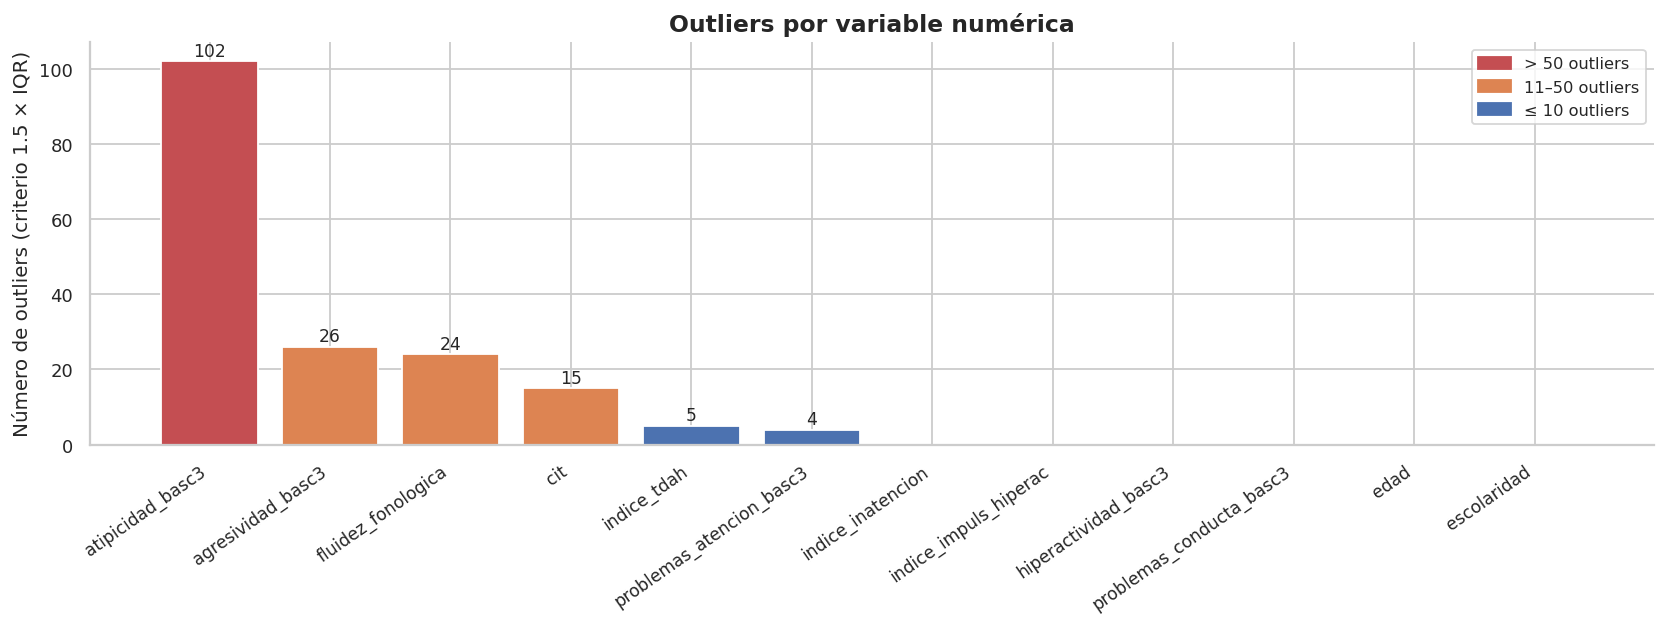

In [16]:
# ── Visualización: outliers por variable ─────────────────────
out_data   = [(c, int(tabla_resumen.loc[c, 'Outliers IQR'])) for c in vars_num_all]
out_sorted = sorted(out_data, key=lambda x: x[1], reverse=True)
cols_o, vals_o = zip(*out_sorted)

colores_o = [C_RED if v > 50 else C_ORG if v > 10 else C_BLUE for v in vals_o]

fig, ax = plt.subplots(figsize=(13, 5))
bars_o = ax.bar(range(len(cols_o)), vals_o, color=colores_o, edgecolor='white')
for bar, val in zip(bars_o, vals_o):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                str(val), ha='center', va='bottom', fontsize=9.5)
ax.set_xticks(range(len(cols_o)))
ax.set_xticklabels(cols_o, rotation=35, ha='right', fontsize=9.5)
ax.set_ylabel("Número de outliers (criterio 1.5 × IQR)")
ax.set_title("Outliers por variable numérica")

leyenda = [
    mpatches.Patch(color=C_RED,  label='> 50 outliers'),
    mpatches.Patch(color=C_ORG,  label='11–50 outliers'),
    mpatches.Patch(color=C_BLUE, label='≤ 10 outliers'),
]
ax.legend(handles=leyenda, fontsize=9)
plt.tight_layout()
plt.show()


📋 **Interpretación — Resumen de normalidad y outliers**

**Tabla de normalidad:**
- **Columna ¿Normal?:** un ✗ significa que Shapiro-Wilk rechaza la hipótesis de normalidad (p < 0.05). Se espera ✗ en todas las variables dado el origen clínico y heterogéneo de la muestra. Esto **no es un defecto de los datos** — es una característica real de muestras clínicas.
- **Asimetría y Curtosis:** complementan el test formal. Una asimetría > 1 o < −1 es considerada alta; curtosis > 3 indica colas pesadas respecto a la normal.

**Gráfica de outliers:**
- El color indica el nivel de atención que merecen: rojo (> 50) requiere análisis cuidadoso; naranja (11–50) merece revisión; azul (≤ 10) es marginal.
- La variable con más outliers IQR no es necesariamente la más problemática: en escalas BASC-3 de muestras clínicas, valores extremos son informativos y clínicamente reales.
- **Antes de excluir cualquier outlier**, verificar si tiene justificación clínica. Un CIT de 70 en esta muestra no es un error — es un caso límite real.

**Implicación para el análisis bivariado:** dado que ninguna variable sigue distribución normal, todos los tests comparativos entre grupos deben ser **no paramétricos**:
- Comparación de dos grupos → Mann-Whitney U
- Comparación de múltiples grupos → Kruskal-Wallis + Dunn post-hoc
- Asociación entre variables numéricas → correlación de Spearman
- Variables categóricas → Chi-cuadrado / Fisher

→ **Cierre del notebook:** el análisis univariado ha caracterizado individualmente las 18 variables del dataset. Los hallazgos más relevantes — distribución multimodal de los índices, desbalance de sexo, elevación clínica de las escalas BASC-3 y asimetría en la fluidez fonológica — establecen el contexto necesario para el análisis bivariado con `etiqueta` como variable objetivo.